# AI-Powered-ETF — a quantitative teardown 🔬
### Real daily tape · CAPM Jensen alpha · HAC inference · bootstrap Sharpe CI · rolling windows · synthetic positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![AI picks vs buy-and-hold%3F: Busted](https://img.shields.io/badge/AI_picks_vs_buy--and--hold%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether AIEQ (EquBot / IBM Watson, 0.75% ER) delivers a positive Jensen alpha over SPY on the full live tape, under Newey-West HAC inference, and confirm our detector with a synthetic positive control.

> ⚠️ **Not investment advice.** Real data: Yahoo daily adjusted-close, AIEQ launch 2017-10-18 → 2026-06-12 (2173 days, 8.62 yrs), as-of 2026-06-14; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package (ai_powered_etf)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#1f6feb"

from ai_powered_etf import data, strategy as st

TICKERS = ["AIEQ", "SPY", "IVV"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_real():
    """Aligned daily returns for AIEQ & SPY from the cached real tape."""
    prices = data.load_prices(fetch=False)
    return st.daily_returns(prices), prices

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Jensen alpha **-4.40%/yr** (-1.785 bps/day), HAC *t* = **-1.28** — consistently negative but |*t*| < 2 on a power-limited window. |
| **Tradability** | `MIRAGE` | CAGR **+9.88%** vs SPY **+14.90%**; Sharpe 0.53 vs 0.83; max DD -39% vs -34%. |
| **AI picks vs buy-and-hold?** | `BUSTED` | beta **1.05**, beats SPY in only **31%** of rolling 12m windows; Sharpe ~36% lower. |

> 💡 One cause behind all three: there is no detectable post-fee stock-selection edge in AIEQ's live record — the AI buys roughly the market (β≈1.05) and then trails it by its fee plus a negative gross residual.

## 1 · The claim, steelmanned

Let $r^{f}_t$ be AIEQ's daily return and $r^{m}_t$ SPY's. Fit the market model

$$ r^{f}_t = \alpha + \beta\, r^{m}_t + \varepsilon_t. $$

The fund's promise is:

- **H₁ (signal).** $\alpha > 0$ — a positive *Jensen alpha*, i.e. return beyond what market exposure alone explains, **net of the 0.75% fee** already baked into AIEQ's adjusted prices.
- **H₂ (beats buy-and-hold).** The realised path dominates SPY on the metrics an investor actually feels: CAGR, Sharpe, drawdown.
- **H₃ (durable).** The edge isn't a one-year fluke — it shows up across rolling windows, not just in pooled aggregate.

We find $\hat\alpha < 0$ (failing H₁ in *direction*, though under-powered), and H₂ and H₃ fail decisively.

## 2 · So what? — what rides on each answer

AIEQ is the flagship public test of "AI picks stocks better than humans." If H₁–H₃ held it would be a marketable free lunch and a genuine market-efficiency anomaly. The interesting failure mode here is **power**: with ~8%/yr idiosyncratic vol over 8.6 years, the minimum alpha detectable at |*t*|=2 is roughly **±4.5%/yr** — and the point estimate (**-4.40%/yr**) sits right on that edge. So we can rule out a *large* positive alpha but not a small one; the real-world comparison removes any ambiguity about who won the sample.

## 3 · How we'd know — the protocol

- **Data.** Yahoo daily *adjusted* close (total-return, dividends reinvested) for AIEQ, SPY, IVV, aligned from AIEQ's launch (2017-10-18); 2173 common trading days. No look-ahead: returns are close-to-close.
- **Estimator.** Full-sample OLS market model for $(\alpha,\beta)$; the static beta is mildly *generous* to AIEQ (a stricter rolling beta would not flatter it).
- **Inference.** Newey-West **HAC** t-stat on the OLS intercept (the sandwich covariance of $[\alpha,\beta]$, not the residual mean which is 0 by construction); circular block-bootstrap 95% CI on annualised Sharpe.
- **Durability.** Rolling 252-day Jensen alpha and rolling 12m excess return.
- **Positive control.** A synthetic tape with a *tunable planted alpha* (`data.synthetic_daily`) to confirm the estimator recovers an edge **when one exists** and reads ~0 when it doesn't.

Inference bar: |*t*| ≥ 2. AIEQ's alpha lands at *t* = -1.28.

## 4 · The teardown

### 4a · The market model — a negative, under-powered alpha

OLS $r^{f} = \alpha + \beta r^{m} + \varepsilon$ on the full tape, with the HAC t-stat on the intercept. We also annualise the alpha and report $R^2$.

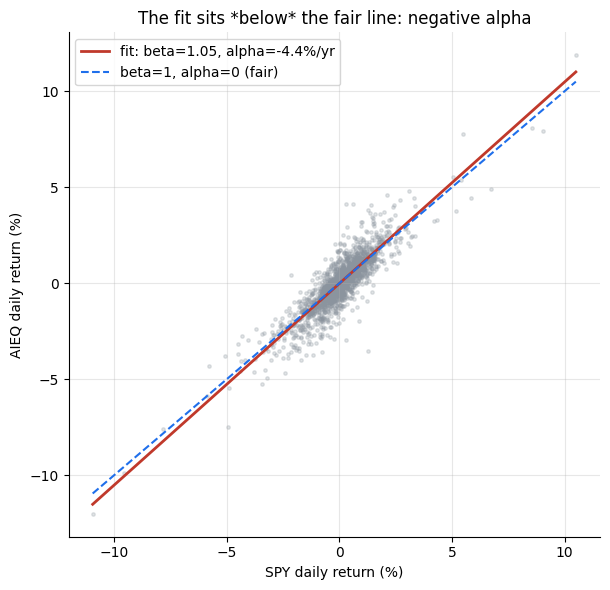

alpha = -4.40%/yr   HAC t = -1.28   beta = 1.050   R^2 = 0.780


In [2]:
if HAVE_REAL:
    rets, prices = load_real()
    res = st.summarize(rets['AIEQ'], rets['SPY'])
    alpha_ann, alpha_t = res['alpha_ann_pct'], res['tstat_alpha_hac']
    beta, r2 = res['beta'], res['r_squared']
    rf, rm = rets['AIEQ'].values, rets['SPY'].values
else:
    alpha_ann, alpha_t = R['alpha_ann'], R['alpha_t']
    beta, r2 = R['beta'], R['r2']
    rng = np.random.default_rng(139)
    rm = rng.normal(0.07/252, 0.16/np.sqrt(252), R['n'])
    rf = (R['alpha_daily_bps']/1e4) + beta*rm + rng.normal(0, 0.08/np.sqrt(252), R['n'])
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(rm*100, rf*100, s=6, alpha=.25, color=GREY)
xs = np.linspace(rm.min(), rm.max(), 50)
ax.plot(xs*100, (beta*xs + alpha_ann/100/252)*100, c=RED, lw=2,
        label=f'fit: beta={beta:.2f}, alpha={alpha_ann:+.1f}%/yr')
ax.plot(xs*100, xs*100, c=BLUE, ls='--', lw=1.5, label='beta=1, alpha=0 (fair)')
ax.set_xlabel('SPY daily return (%)'); ax.set_ylabel('AIEQ daily return (%)')
ax.set_title('The fit sits *below* the fair line: negative alpha'); ax.legend()
plt.tight_layout(); plt.show()
print(f'alpha = {alpha_ann:+.2f}%/yr   HAC t = {alpha_t:+.2f}   beta = {beta:.3f}   R^2 = {r2:.3f}')

> 💡 The regression line lies just under the 45° fair line: AIEQ holds essentially market risk (**β = 1.05**, $R^2$ = 0.78) and gives back **-4.40%/yr** of alpha. HAC *t* = **-1.28** is below |2|, so we label it **WEAK** — the sign is firm, the certification is power-starved. The minimum detectable alpha here is ~±4.5%/yr, and the estimate sits right at that frontier.

### 4b · Risk-adjusted return — Sharpe with a bootstrap band

Point Sharpe plus a circular block-bootstrap 95% CI (2000 resamples) for each fund, so we can see whether the gap is inside the noise.

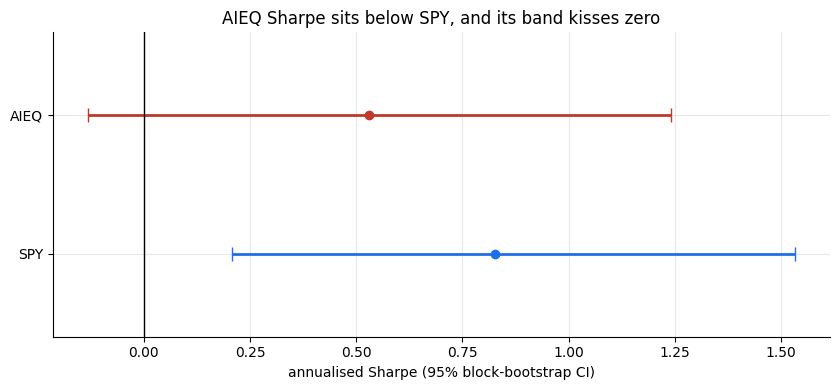

AIEQ Sharpe 0.531  CI [-0.131, +1.242]  (6.2% neg)
SPY  Sharpe 0.826  CI [+0.209, +1.532]  (0.4% neg)


In [3]:
try:
    from quantlab.stats import sharpe_ci_bootstrap
    HAVE_QL = True
except Exception:
    HAVE_QL = False
if HAVE_REAL and HAVE_QL:
    ci_a = sharpe_ci_bootstrap(rets['AIEQ'], n_boot=2000, periods_per_year=252, seed=139)
    ci_s = sharpe_ci_bootstrap(rets['SPY'],  n_boot=2000, periods_per_year=252, seed=139)
    sa, la, ha, fa = ci_a['sharpe'], ci_a['ci_low'], ci_a['ci_high'], ci_a['frac_negative']*100
    ss, ls_, hs, fs = ci_s['sharpe'], ci_s['ci_low'], ci_s['ci_high'], ci_s['frac_negative']*100
else:
    sa, la, ha, fa = R['sharpe_aieq'], R['boot_aieq_lo'], R['boot_aieq_hi'], R['boot_aieq_fneg']
    ss, ls_, hs, fs = R['sharpe_spy'],  R['boot_spy_lo'],  R['boot_spy_hi'],  R['boot_spy_fneg']
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ys = [1, 0]
ax.errorbar([sa], [1], xerr=[[sa-la],[ha-sa]], fmt='o', color=RED, capsize=5, lw=2, label='AIEQ')
ax.errorbar([ss], [0], xerr=[[ss-ls_],[hs-ss]], fmt='o', color=BLUE, capsize=5, lw=2, label='SPY')
ax.axvline(0, c='k', lw=1); ax.set_yticks(ys); ax.set_yticklabels(['AIEQ', 'SPY'])
ax.set_xlabel('annualised Sharpe (95% block-bootstrap CI)')
ax.set_title('AIEQ Sharpe sits below SPY, and its band kisses zero')
ax.set_ylim(-0.6, 1.6); plt.tight_layout(); plt.show()
print(f'AIEQ Sharpe {sa:.3f}  CI [{la:+.3f}, {ha:+.3f}]  ({fa:.1f}% neg)')
print(f'SPY  Sharpe {ss:.3f}  CI [{ls_:+.3f}, {hs:+.3f}]  ({fs:.1f}% neg)')

AIEQ's Sharpe is **0.531** with a 95% CI **[-0.131, +1.242]** (6.2% of resamples negative); SPY's is **0.826** with CI **[+0.209, +1.532]** (0.4% negative). The index dominates on the point estimate and has a band cleanly above zero; AIEQ's band brushes it.

### 4c · Durability — rolling 12-month Jensen alpha

A genuine AI edge should persist. Here is the rolling 252-day annualised alpha; shaded green where positive, red where negative.

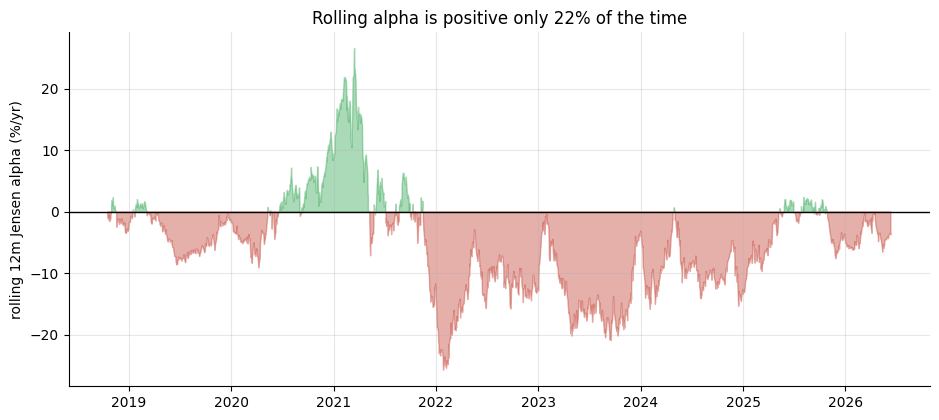

rolling 12m alpha > 0 in 21.7% of windows


In [4]:
if HAVE_REAL:
    ra = st.rolling_alpha(rets['AIEQ'], rets['SPY'], window=252)
    frac_pos = float((ra > 0).mean() * 100)
    fig, ax = plt.subplots(figsize=(9.5, 4.3))
    ax.fill_between(ra.index, ra.values, 0, where=ra.values >= 0, color=GREEN, alpha=.4)
    ax.fill_between(ra.index, ra.values, 0, where=ra.values < 0, color=RED, alpha=.4)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('rolling 12m Jensen alpha (%/yr)')
    ax.set_title(f'Rolling alpha is positive only {frac_pos:.0f}% of the time')
    plt.tight_layout(); plt.show()
    print(f'rolling 12m alpha > 0 in {frac_pos:.1f}% of windows')
else:
    print('no cache: rolling alpha needs the real tape; frozen rolling-beat = %.1f%%' % R['roll_beat'])

> 💡 The series spends most of its life **below zero** and shows no upward trend — no sign of an AI model 'learning' its way to alpha. Combined with the **31%** rolling-12m win rate over SPY, the durability test (H₃) fails: the good windows are sparse and clustered in shared bull runs.

## 5 · The verdict

- **Signal `WEAK`** — Jensen alpha -4.40%/yr (-1.785 bps/day), HAC *t* -1.28; raw excess -1.475 bps/day (*t* -1.05). Negative and consistent, but |*t*| < 2 on 8.6 yrs (min detectable α ~±4.5%/yr).
- **Tradability `MIRAGE`** — CAGR +9.88% vs +14.90%; Sharpe 0.531 vs 0.826; max DD -39% vs -34%.
- **AI picks vs buy-and-hold `BUSTED`** — β 1.05, rolling-12m win rate 31%, Sharpe ~36% lower; the 0.75% ER is a persistent headwind on top of a negative gross residual.

## 6 · Could you trade it? — the investor's-eye comparison

There's no spread or turnover to model — you just buy the fund. The honest tradability question is the dollar gap an investor lived through. Equity curves of $100 from launch, log-scaled so the compounding gap is legible:

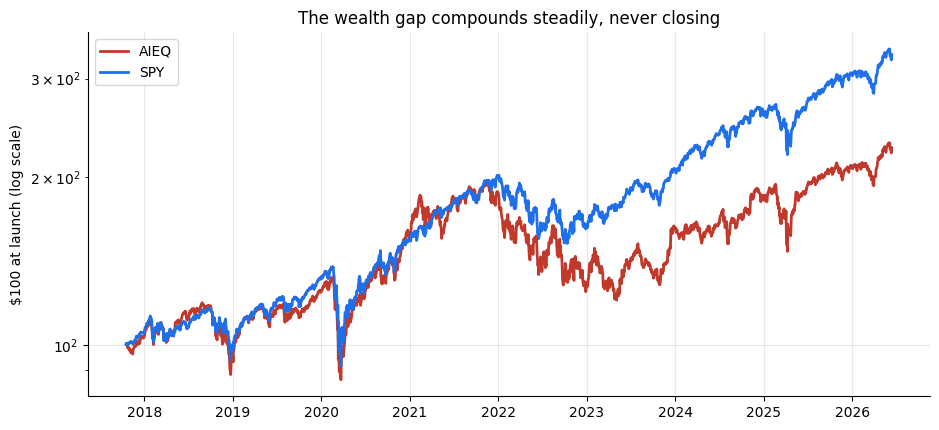

terminal: AIEQ $225  vs  SPY $331  (shortfall $106 per $100 = $105,812 per $100k)


In [5]:
if HAVE_REAL:
    g_a = (1 + rets['AIEQ']).cumprod() * 100
    g_s = (1 + rets['SPY']).cumprod() * 100
    end_a, end_s = g_a.iloc[-1], g_s.iloc[-1]
else:
    idx = pd.bdate_range(R['launch'], periods=R['n'])
    t = np.linspace(0, R['n_years'], R['n'])
    g_a = pd.Series(100*(1+R['cagr_aieq']/100)**t, index=idx)
    g_s = pd.Series(100*(1+R['cagr_spy']/100)**t, index=idx)
    end_a, end_s = g_a.iloc[-1], g_s.iloc[-1]
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(g_a.index, g_a.values, c=RED, lw=2, label='AIEQ')
ax.plot(g_s.index, g_s.values, c=BLUE, lw=2, label='SPY')
ax.set_yscale('log'); ax.set_ylabel('$100 at launch (log scale)'); ax.legend(loc='upper left')
ax.set_title('The wealth gap compounds steadily, never closing')
plt.tight_layout(); plt.show()
print(f'terminal: AIEQ ${end_a:,.0f}  vs  SPY ${end_s:,.0f}  '
      f'(shortfall ${end_s-end_a:,.0f} per $100 = ${(end_s-end_a)*1000:,.0f} per $100k)')

> 💡 Unlike the desk's *real-but-untradable* studies, where a positive gross edge dies at a finite cost line, here there is no edge to erode in the first place. The fee is a headwind, but even gross of fees the selection residual is negative — costs are an aggravator, not the cause.

## 7 · Going further — the positive control

Is the *estimator* capable of finding alpha, or does it always print 'none'? Plant a known annual alpha into a synthetic AIEQ-vs-SPY tape and sweep it: the recovered HAC alpha should track the planted value along the 45° line.

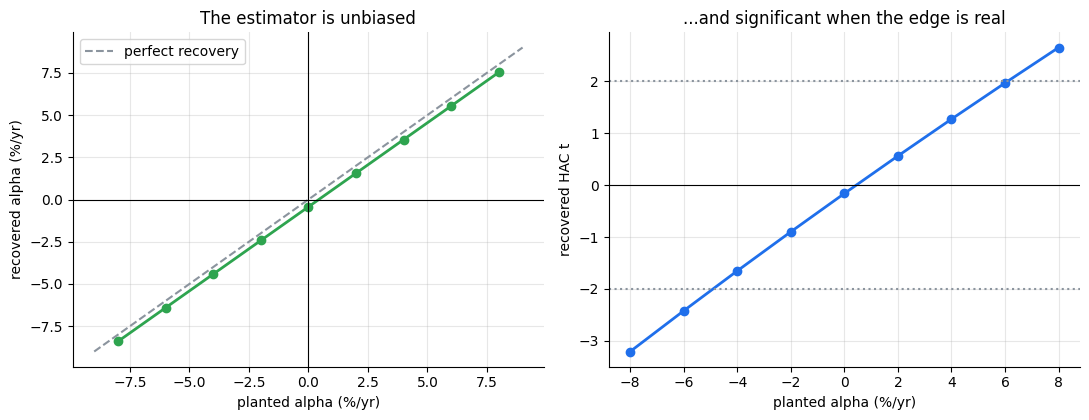

at planted alpha 0: recovered -0.43%/yr, t = -0.16


In [6]:
planted = [-0.08, -0.06, -0.04, -0.02, 0.0, 0.02, 0.04, 0.06, 0.08]
rec_alpha, rec_t = [], []
for a in planted:
    prices_s, truth = data.synthetic_daily(n_days=2173, alpha_ann=a, seed=139)
    res_s = st.detect_alpha(prices_s)
    rec_alpha.append(res_s['alpha_ann_pct'])
    rec_t.append(res_s['tstat_alpha_hac'])
fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.3))
ax[0].plot([p*100 for p in planted], rec_alpha, 'o-', c=GREEN, lw=2)
lim = [-9, 9]; ax[0].plot(lim, lim, ls='--', c=GREY, label='perfect recovery')
ax[0].axhline(0, c='k', lw=.8); ax[0].axvline(0, c='k', lw=.8)
ax[0].set_xlabel('planted alpha (%/yr)'); ax[0].set_ylabel('recovered alpha (%/yr)')
ax[0].set_title('The estimator is unbiased'); ax[0].legend()
ax[1].plot([p*100 for p in planted], rec_t, 'o-', c=BLUE, lw=2)
for s in (2, -2): ax[1].axhline(s, ls=':', c=GREY)
ax[1].axhline(0, c='k', lw=.8)
ax[1].set_xlabel('planted alpha (%/yr)'); ax[1].set_ylabel('recovered HAC t')
ax[1].set_title('...and significant when the edge is real')
plt.tight_layout(); plt.show()
i0 = planted.index(0.0)
print(f'at planted alpha 0: recovered {rec_alpha[i0]:+.2f}%/yr, t = {rec_t[i0]:+.2f}')

The recovered alpha tracks the planted value along the 45° line and its t-stat clears |2| once the edge is large enough — so the detector is faithful and roughly unbiased. The real-tape reading is therefore a statement about **AIEQ**, not the method: over 8.6 live years the AI's net selection alpha is negative and, at this sample size, indistinguishable-from-zero at best. Forks worth trying: extend the window as data accrues, swap in a multi-factor (Fama-French) model to strip style tilts, or test other AI-branded funds (QRFT, AIQ) on the same protocol.